Importing Libraries

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_validate, StratifiedKFold, cross_val_predict
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve

from xgboost import XGBClassifier
from sklearn.utils.class_weight import compute_class_weight


Importing Data

In [11]:
df = pd.read_csv("../data/processed/modeling_dataset.csv")

Selecting Feature Set

In [12]:

chronic_condition_features = [
    'CVDINFR4',   # Heart attack
    'CVDCRHD4',   # Coronary heart disease
    'CVDSTRK3',   # Stroke
    'ASTHMA3',    # Asthma
    'CHCSCNC1',   # Skin cancer
    'CHCOCNC1',   # Other cancer
    'CHCCOPD3',   # COPD
    'ADDEPEV3',   # Depression
    'CHCKDNY2'    # Kidney disease
]

df['chronic_count'] = df[chronic_condition_features].sum(axis=1)

features = [
    '_STATE',
    'SEXVAR',
    'MARITAL',
    'EDUCA',
    'RENTHOM1',
    '_AGE80',
    '_RACEGR3',
    'INCOME3',
    'EMPLOY1',
    'VETERAN3',
    'PRIMINS2',
    'PERSDOC3',
    'CHECKUP1',
    'GENHLTH',
    'PHYSHLTH',
    'MENTHLTH',
    'POORHLTH',
    'CVDINFR4',
    'CVDCRHD4',
    'CVDSTRK3',
    'ASTHMA3',
    'CHCSCNC1',
    'CHCOCNC1',
    'CHCCOPD3',
    'ADDEPEV3',
    'CHCKDNY2',
    'EXERANY2',
    'SMOKE100',
    '_BMI5',
    'LASTDEN4',
    'RMVTETH4',
    'chronic_count'
]


X = df[features]
y = df['MEDCOST1_binary']

Splitting dataset and creating weights

In [13]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

negative = (y_train == 0).sum()
positive = (y_train == 1).sum()

scale_pos_weight = negative / positive

print(scale_pos_weight)


classes = np.unique(y_train)

weights = compute_class_weight(class_weight="balanced",classes=classes,y=y_train)

class_weights = dict(zip(classes, weights))


print(class_weights)

9.515912366676275
{np.int64(0): np.float64(0.5525435692063483), np.int64(1): np.float64(5.257956183338138)}


Creating Model Pipelines

In [14]:
log_model = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("classifier",
         LogisticRegression(
             class_weight=class_weights,
             max_iter=2000,
             random_state=42
         ))
    ]
)

rf_model = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("classifier", RandomForestClassifier(
             n_estimators=400,
             class_weight=class_weights,
             random_state=42
         ))
    ]
)

xgb_model = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("classifier", XGBClassifier(
             n_estimators=400,
             max_depth=6,
             learning_rate=0.05,
             subsample=0.8,
             colsample_bytree=0.8,
             scale_pos_weight=scale_pos_weight,
             random_state=42,
             eval_metric="logloss"
         ))
    ]
)

scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc"
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

Logisitc Regression

In [15]:
log_model.fit(X_train, y_train)
y_prob = log_model.predict_proba(X_test)[:, 1]
y_pred = (y_prob >= 0.3).astype(int)

log_f1 = f1_score(y_test, y_pred)
log_roc = roc_auc_score(y_test, y_prob)

print("Logistic Regression")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1:", log_f1)
print("ROC-AUC:", log_roc)

print()

log_results = cross_validate(log_model, X, y, cv=cv, scoring=scoring)

print("Logistic Regression Cross Validation")
for metric in scoring:
    mean = log_results[f"test_{metric}"].mean()
    std = log_results[f"test_{metric}"].std()

    print(f"{metric}: {mean:.3f} ± {std:.3f}")

Logistic Regression
Accuracy: 0.5862280701754385
Precision: 0.17531002122667858
Recall: 0.9046466044044736
F1: 0.29370367597514413
ROC-AUC: 0.835747996821674

Logistic Regression Cross Validation
accuracy: 0.770 ± 0.001
precision: 0.255 ± 0.001
recall: 0.737 ± 0.005
f1: 0.378 ± 0.002
roc_auc: 0.836 ± 0.003


Random Forest

In [16]:
rf_model.fit(X_train, y_train)
y_prob = rf_model.predict_proba(X_test)[:, 1]
y_pred = (y_prob >= 0.3).astype(int)

rf_f1 = f1_score(y_test, y_pred)
rf_roc = roc_auc_score(y_test, y_prob)

print("Random Forest")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1:", rf_f1)
print("ROC-AUC:", rf_roc)

print()

rf_results = cross_validate(rf_model, X, y, cv=cv, scoring=scoring)

print("Random Forest Cross Validation")
for metric in scoring:
    mean = rf_results[f"test_{metric}"].mean()
    std = rf_results[f"test_{metric}"].std()

    print(f"{metric}: {mean:.3f} ± {std:.3f}")

Random Forest
Accuracy: 0.9058552631578948
Precision: 0.5076463350325189
Recall: 0.33298743226104
F1: 0.40217239938727195
ROC-AUC: 0.8470885463811486

Random Forest Cross Validation
accuracy: 0.912 ± 0.000
precision: 0.705 ± 0.008
recall: 0.133 ± 0.003
f1: 0.224 ± 0.005
roc_auc: 0.848 ± 0.003


XGBoost

In [18]:
xgb_model.fit(X_train, y_train)
y_prob = xgb_model.predict_proba(X_test)[:, 1]
y_pred = (y_prob >= 0.7).astype(int)

XGBoost_f1 = f1_score(y_test, y_pred)
XGBoost_roc = roc_auc_score(y_test, y_prob)

print("XGBoost")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1:", XGBoost_f1)
print("ROC-AUC:", XGBoost_roc)

print()

xgb_results = cross_validate(xgb_model, X, y, cv=cv, scoring=scoring)

print("XGBoost Cross Validation")
for metric in scoring:
    mean = xgb_results[f"test_{metric}"].mean()
    std = xgb_results[f"test_{metric}"].std()

    print(f"{metric}: {mean:.3f} ± {std:.3f}")

print()



y_prob = cross_val_predict(xgb_model, X, y, cv=cv, method="predict_proba")[:, 1]

threshold = 0.7
y_pred = (y_prob >= threshold).astype(int)

print("XGBoost Cross Validation w/ Threshold")
print("Accuracy:", accuracy_score(y, y_pred))
print("Precision:", precision_score(y, y_pred))
print("Recall:", recall_score(y, y_pred))
print("F1:", f1_score(y, y_pred))
print("ROC-AUC:", XGBoost_roc)

XGBoost
Accuracy: 0.8726754385964912
Precision: 0.38212882008502447
Recall: 0.5492909028017987
F1: 0.4507095553453169
ROC-AUC: 0.8570563438031861

XGBoost Cross Validation
accuracy: 0.776 ± 0.001
precision: 0.266 ± 0.001
recall: 0.774 ± 0.005
f1: 0.396 ± 0.002
roc_auc: 0.857 ± 0.003

XGBoost Cross Validation w/ Threshold
Accuracy: 0.8733259210038663
Precision: 0.3848368522072937
Recall: 0.5548509097617784
F1: 0.4544638893873426
ROC-AUC: 0.8570563438031861


In [31]:
xgb_model.fit(X_train, y_train)

y_prob = xgb_model.predict_proba(X_test)[:, 1]
y_pred = (y_prob >= threshold).astype(int)

errors = X_test.copy()

errors["Actual"] = y_test.values
errors["Predicted"] = y_pred
errors["Probability"] = y_prob

errors["Correct"] = errors["Actual"] == errors["Predicted"]

misclassified = errors[errors["Correct"] == False]

misclassified.head()

false_negative = errors[
    (errors["Actual"] == 1) &
    (errors["Predicted"] == 0)
]

false_negative.head()

,_STATE,SEXVAR,MARITAL,EDUCA,RENTHOM1,_AGE80,_RACEGR3,INCOME3,EMPLOY1,VETERAN3,...,EXERANY2,SMOKE100,_BMI5,LASTDEN4,RMVTETH4,chronic_count,Actual,Predicted,Probability,Correct
173469,25.0,1.0,5.0,4.0,1.0,80.0,1.0,4.0,7.0,0.0,...,1.0,0.0,28.89,1.0,8.0,2.0,1,0,0.205384,False
5526,2.0,2.0,3.0,6.0,1.0,69.0,1.0,NaN,7.0,0.0,...,0.0,0.0,27.37,1.0,1.0,1.0,1,0,0.317886,False
33512,8.0,1.0,2.0,6.0,1.0,76.0,1.0,2.0,7.0,0.0,...,0.0,0.0,31.00,1.0,2.0,3.0,1,0,0.563578,False
329597,40.0,2.0,4.0,5.0,2.0,41.0,1.0,6.0,1.0,0.0,...,1.0,1.0,34.54,1.0,2.0,0.0,1,0,0.617591,False
403858,53.0,1.0,1.0,6.0,1.0,47.0,1.0,9.0,1.0,0.0,...,1.0,0.0,30.04,1.0,2.0,1.0,1,0,0.539978,False


In [34]:
false_negative.iloc[2]

_STATE                8.0
SEXVAR                1.0
MARITAL               2.0
EDUCA                 6.0
RENTHOM1              1.0
_AGE80               76.0
_RACEGR3              1.0
INCOME3               2.0
EMPLOY1               7.0
VETERAN3              0.0
PRIMINS2              5.0
PERSDOC3              1.0
CHECKUP1              1.0
GENHLTH               4.0
PHYSHLTH             15.0
MENTHLTH             30.0
POORHLTH             20.0
CVDINFR4              1.0
CVDCRHD4              1.0
CVDSTRK3              0.0
ASTHMA3               0.0
CHCSCNC1              0.0
CHCOCNC1              0.0
CHCCOPD3              0.0
ADDEPEV3              1.0
CHCKDNY2              0.0
EXERANY2              0.0
SMOKE100              0.0
_BMI5                31.0
LASTDEN4              1.0
RMVTETH4              2.0
chronic_count         3.0
Actual                  1
Predicted               0
Probability      0.563578
Correct             False
Name: 33512, dtype: object

Retrieving Feature Importance

In [ ]:
xgb = xgb_model.named_steps["classifier"]

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": xgb.feature_importances_
})

importance = importance.sort_values("Importance", ascending=False)
print(importance.head(15))

     Feature  Importance
10  PRIMINS2    0.120621
15  MENTHLTH    0.083884
7    INCOME3    0.078486
16  POORHLTH    0.072036
4   RENTHOM1    0.068975
5     _AGE80    0.064433
29  LASTDEN4    0.060534
13   GENHLTH    0.054619
12  CHECKUP1    0.044191
24  ADDEPEV3    0.032226
6   _RACEGR3    0.031204
11  PERSDOC3    0.028642
8    EMPLOY1    0.025736
14  PHYSHLTH    0.021618
30  RMVTETH4    0.020222


Quick Comparison of Cross Validation results

In [ ]:
comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "XGBoost"
    ],
    "Accuracy": [
        log_results["test_accuracy"].mean(),
        rf_results["test_accuracy"].mean(),
        xgb_results["test_accuracy"].mean()
    ],
    "Precision": [
        log_results["test_precision"].mean(),
        rf_results["test_precision"].mean(),
        xgb_results["test_precision"].mean()
    ],
    "Recall": [
        log_results["test_recall"].mean(),
        rf_results["test_recall"].mean(),
        xgb_results["test_recall"].mean()
    ],
    "F1": [
        log_results["test_f1"].mean(),
        rf_results["test_f1"].mean(),
        xgb_results["test_f1"].mean()
    ],
    "ROC-AUC": [
        log_results["test_roc_auc"].mean(),
        rf_results["test_roc_auc"].mean(),
        xgb_results["test_roc_auc"].mean()
    ]
})

comparison

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,0.769768,0.254597,0.737149,0.378474,0.836093
1,Random Forest,0.912289,0.705040,0.133478,0.224448,0.847691
2,XGBoost,0.775567,0.266105,0.773701,0.396007,0.857410


The XGBoost Model seems to perform the best according to the ROC-AUC score and F1 score being the highest. The logistic regression model had the highest recall when given a lower threshold while the Random Forest model was the weakest overall. The most important features used to determine at-risk people was their insurance status, mental health, and income. In other words, it generally seems true that the most important factors in deciding whether someone avoided medical care due to cost is their financial status and their current health.

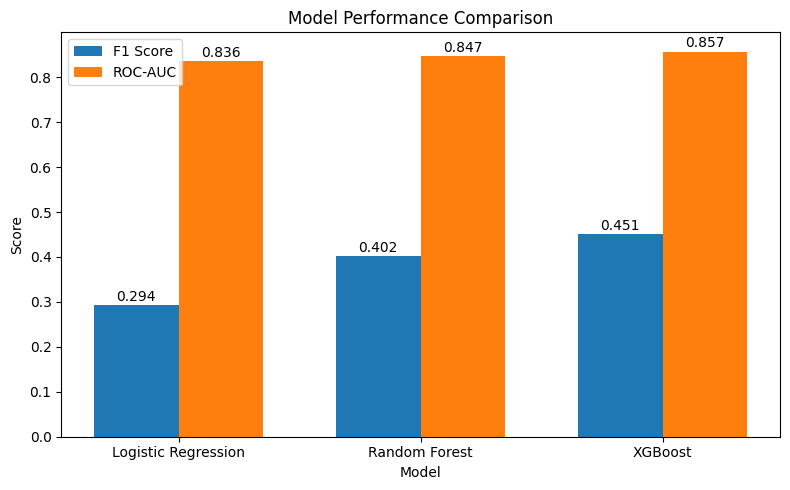

In [ ]:
models = ["Logistic Regression", "Random Forest", "XGBoost"]

f1_scores = [log_f1, rf_f1, XGBoost_f1]
roc_auc_scores = [log_roc, rf_roc, XGBoost_roc]

x = np.arange(len(models))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))

bars1 = ax.bar(x - width/2, f1_scores, width, label="F1 Score")
bars2 = ax.bar(x + width/2, roc_auc_scores, width, label="ROC-AUC")

ax.set_title("Model Performance Comparison")
ax.set_ylabel("Score")
ax.set_xlabel("Model")
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.legend()

for bar in bars1:
    height = bar.get_height()
    ax.annotate(f"{height:.3f}", xy=(bar.get_x() + bar.get_width()/2, height), xytext=(0, 3), textcoords="offset points", ha="center")

for bar in bars2:
    height = bar.get_height()
    ax.annotate(f"{height:.3f}", xy=(bar.get_x() + bar.get_width()/2, height), xytext=(0, 3), textcoords="offset points", ha="center")

plt.tight_layout()
plt.show()

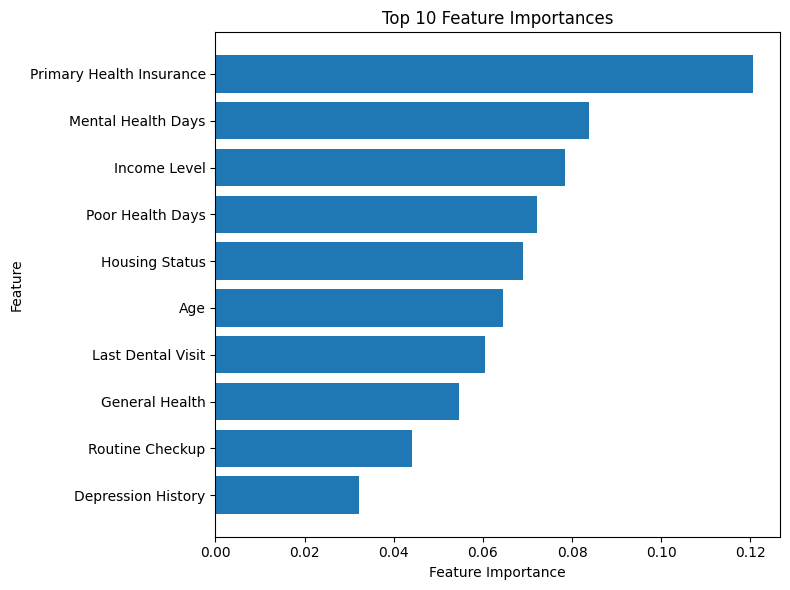

In [ ]:
feature_labels = {
    "_STATE": "State",
    "SEXVAR": "Sex",
    "MARITAL": "Marital Status",
    "EDUCA": "Education Level",
    "RENTHOM1": "Housing Status",
    "_AGE80": "Age",
    "_RACEGR3": "Race/Ethnicity",
    "INCOME3": "Income Level",
    "EMPLOY1": "Employment Status",
    "VETERAN3": "Veteran Status",
    "PRIMINS2": "Primary Health Insurance",
    "PERSDOC3": "Personal Doctor",
    "CHECKUP1": "Routine Checkup",
    "GENHLTH": "General Health",
    "PHYSHLTH": "Physical Health Days",
    "MENTHLTH": "Mental Health Days",
    "POORHLTH": "Poor Health Days",
    "CVDINFR4": "Heart Attack History",
    "CVDCRHD4": "Coronary Heart Disease",
    "CVDSTRK3": "Stroke History",
    "ASTHMA3": "Asthma",
    "CHCSCNC1": "Skin Cancer",
    "CHCOCNC1": "Other Cancer",
    "CHCCOPD3": "COPD",
    "ADDEPEV3": "Depression History",
    "CHCKDNY2": "Kidney Disease",
    "EXERANY2": "Exercise Participation",
    "SMOKE100": "Smoking History",
    "_BMI5": "Body Mass Index (BMI)",
    "LASTDEN4": "Last Dental Visit",
    "RMVTETH4": "Teeth Removed"
}

importance["Feature"] = (
    importance["Feature"]
    .map(feature_labels)
)

top10 = (
    importance
    .sort_values("Importance", ascending=False)
    .head(10)
)

# Plot
plt.figure(figsize=(8, 6))
plt.barh(top10["Feature"], top10["Importance"])
plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Top 10 Feature Importances")
plt.gca().invert_yaxis()  # highest importance at top
plt.tight_layout()
plt.show()

   Threshold  Accuracy  Precision    Recall        F1
0        0.2  0.524471   0.160797  0.948228  0.274967
1        0.3  0.629215   0.192279  0.905749  0.317216
2        0.4  0.709592   0.226169  0.848189  0.357113
3        0.5  0.775567   0.266105  0.773701  0.396008
4        0.6  0.829804   0.315981  0.678043  0.431073
5        0.7  0.873326   0.384837  0.554851  0.454464
6        0.8  0.903416   0.490196  0.391463  0.435301


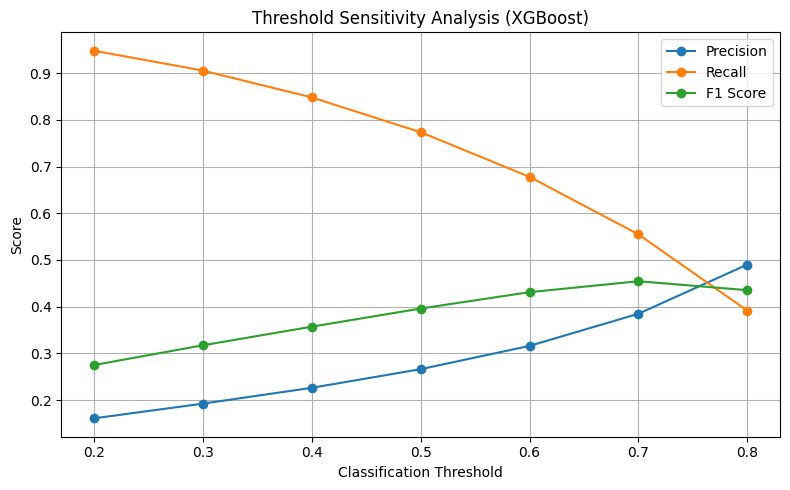

In [24]:
xgb_model.fit(X_train, y_train)

y_prob = cross_val_predict(xgb_model, X, y, cv=cv, method="predict_proba")[:, 1]

thresholds = np.arange(0.2, 0.81, 0.1)

results = []

for t in thresholds:

    y_pred = (y_prob >= t).astype(int)

    results.append({
        "Threshold": t,
        "Accuracy": accuracy_score(y, y_pred),
        "Precision": precision_score(y, y_pred, zero_division=0),
        "Recall": recall_score(y, y_pred, zero_division=0),
        "F1": f1_score(y, y_pred, zero_division=0)
    })

sensitivity_df = pd.DataFrame(results)

print(sensitivity_df)

plt.figure(figsize=(8,5))

plt.plot(sensitivity_df["Threshold"], sensitivity_df["Precision"], marker='o', label="Precision")

plt.plot(sensitivity_df["Threshold"], sensitivity_df["Recall"], marker='o', label="Recall")

plt.plot( sensitivity_df["Threshold"], sensitivity_df["F1"], marker='o', label="F1 Score")

plt.xlabel("Classification Threshold")
plt.ylabel("Score")
plt.title("Threshold Sensitivity Analysis (XGBoost)")
plt.xticks(thresholds)
plt.grid(True)

plt.legend()

plt.tight_layout()
plt.show()

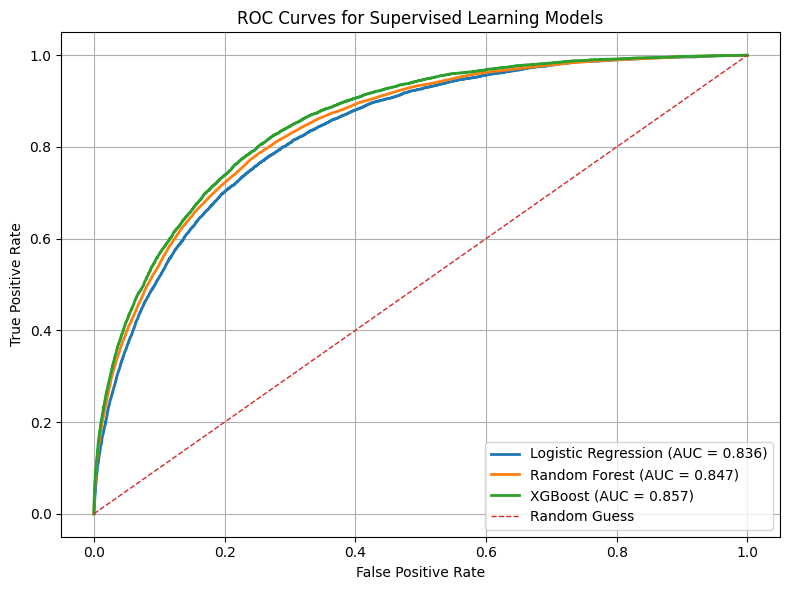

In [20]:
log_model.fit(X_train, y_train)
rf_model.fit(X_train, y_train)
xgb_model.fit(X_train, y_train)

log_prob = log_model.predict_proba(X_test)[:, 1]
rf_prob = rf_model.predict_proba(X_test)[:, 1]
xgb_prob = xgb_model.predict_proba(X_test)[:, 1]

log_fpr, log_tpr, _ = roc_curve(y_test, log_prob)
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_prob)
xgb_fpr, xgb_tpr, _ = roc_curve(y_test, xgb_prob)

log_auc = roc_auc_score(y_test, log_prob)
rf_auc = roc_auc_score(y_test, rf_prob)
xgb_auc = roc_auc_score(y_test, xgb_prob)

plt.figure(figsize=(8, 6))

plt.plot(log_fpr, log_tpr, linewidth=2, label=f"Logistic Regression (AUC = {log_auc:.3f})")

plt.plot(rf_fpr, rf_tpr, linewidth=2, label=f"Random Forest (AUC = {rf_auc:.3f})")

plt.plot(xgb_fpr, xgb_tpr, linewidth=2, label=f"XGBoost (AUC = {xgb_auc:.3f})")


plt.plot([0, 1], [0, 1], linestyle="--", linewidth=1, label="Random Guess")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves for Supervised Learning Models")

plt.legend(loc="lower right")
plt.grid(True)

plt.tight_layout()
plt.show()

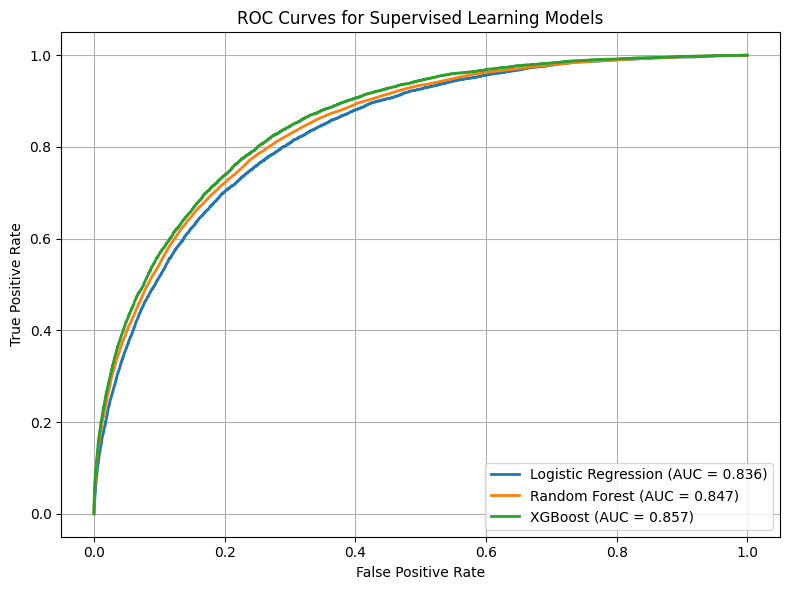

In [22]:
plt.figure(figsize=(8, 6))

plt.plot(log_fpr, log_tpr, linewidth=2, label=f"Logistic Regression (AUC = {log_auc:.3f})")

plt.plot(rf_fpr, rf_tpr, linewidth=2, label=f"Random Forest (AUC = {rf_auc:.3f})")

plt.plot(xgb_fpr, xgb_tpr, linewidth=2, label=f"XGBoost (AUC = {xgb_auc:.3f})")



plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves for Supervised Learning Models")

plt.legend(loc="lower right")
plt.grid(True)

plt.tight_layout()
plt.show()